# Классификация тональности текста

Цель: построить модель машинного обучения для **классификации тональности текста** на три класса:

- **позитив**
- **нейтрал**
- **негатив**

Задача включает:
- предобработку данных
- обучение модели
- оценку качества
- анализ ошибок
- и предложение улучшений

Основной акцент делается не только на достижении высокой точности, но и на понимании **поведения модели**, особенно на несбалансированных данных.

---

## Датасет

Датасет состоит из:

- `text` — входной текст (пользовательский контент)
- `sentiment` — целевая переменная (3 класса)

Ключевые наблюдения на этапе первичного анализа:
- небольшой датасет (~3000 наблюдений)
- умеренный дисбаланс классов:
  - позитив ~45%
  - нейтрал ~37%
  - негатив ~17%
- несогласованность в названиях классов (например, "позит", "позитивный") — нормализованы в процессе предобработки

---

## Подход

### 1. Предобработка данных
- удалены пропущенные значения
- нормализованы метки классов
- базовая очистка текста

---

### 2. Разбиение на train / validation
- разбиение 80 / 20
- стратификация по таргету
- `random_state = 42`

---

### 3. Базовая модель
- **TF-IDF векторизация**
- **Логистическая регрессия**

Результаты:
- Accuracy ≈ **0.70**
- F1 (weighted) ≈ **0.67**
- F1 (macro) ≈ **0.59**

---

### Ключевая проблема (baseline)

Confusion matrix и метрики по классам показали:

очень низкий **recall для класса "негатив"**

Модель:
- редко предсказывает негативный класс
- склонна выбирать доминирующие классы

---

### 4. Эксперимент 1: n-grams

- TF-IDF расширен биграммами (`ngram_range=(1,2)`)

Результат:
- отсутствует улучшение метрик
- структура ошибок не изменилась

Вывод:
> Представление признаков не является основным ограничением.

---

### 5. Эксперимент 2: class_weight='balanced'

- применена балансировка классов в логистической регрессии

Результаты:
- Accuracy ↓ немного
- F1 (weighted) ↑
- F1 (macro) ↑ значительно

---

## Ключевые выводы

### Дисбаланс классов — основная проблема

Базовая модель:
- игнорирует минорный класс ("негатив")

Сбалансированная модель:
- лучше распознаёт негатив

---

### Наблюдаемый trade-off

| Метрика | Эффект |
|--------|--------|
| Accuracy | немного хуже |
| Recall (негатив) | значительно лучше |
| Precision (негатив) | снизился |
| F1 macro | значительно улучшился |

---

Интерпретация:

Модель переходит от:
- **консервативной стратегии** (избегает предсказания негатива)

к:
- **агрессивной стратегии** (активно выявляет негатив)

---

### Переобучение

Все модели демонстрируют:
- значительный разрыв между train и validation

Вывод:
> Переобучение присутствует и не устраняется ни за счёт признаков, ни за счёт балансировки классов.

---

## Итоговое заключение

- Основное ограничение — **дисбаланс классов**, а не признаки
- n-grams не улучшают качество
- балансировка классов значительно улучшает **равномерность качества по классам**
- наблюдается явный trade-off между:
  - общей точностью
  - и качеством по классам

---

## Возможные улучшения

- подбор гиперпараметров (регуляризация)
- более продвинутые модели (например, линейный SVM)
- улучшенная предобработка текста (лемматизация, стоп-слова)
- настройка порогов классификации
- увеличение объёма данных

---

## Итог

Финальная модель с балансировкой классов даёт более **сбалансированное и осмысленное решение**, несмотря на небольшое снижение accuracy.

> В данной задаче **F1 (особенно macro)** является более информативной метрикой, чем accuracy.

# Text Sentiment Classification

The goal is to build a machine learning model for **text sentiment classification** into three classes:

- **позитив**
- **нейтрал**
- **негатив**

The task includes:
- data preprocessing
- model training
- evaluation
- error analysis
- and proposing improvements

The main focus is not only on achieving high accuracy, but on understanding **model behavior**, especially on imbalanced data.

---

## Dataset

The dataset consists of:

- `text` — input text (user-generated content)
- `sentiment` — target label (3 classes)

Key observations from initial exploration:
- small dataset (~3000 samples)
- moderate class imbalance:
  - позитив ~45%
  - нейтрал ~37%
  - негатив ~17%
- inconsistent labels (e.g. "позит", "позитивный") — normalized during preprocessing

---

## Approach

### 1. Data preprocessing
- removed missing values
- normalized sentiment labels
- basic cleaning

---

### 2. Train / Validation split
- 80 / 20 split
- stratified by target
- `random_state = 42`

---

### 3. Baseline model
- **TF-IDF vectorization**
- **Logistic Regression**

Results:
- Accuracy ≈ **0.70**
- F1 (weighted) ≈ **0.67**
- F1 (macro) ≈ **0.59**

---

### Key issue (baseline)

Confusion matrix and class-level metrics showed:

very low **recall for "negative"**

The model:
- rarely predicts negative class
- prefers majority classes

---

### 4. Experiment 1: n-grams

- TF-IDF extended with bigrams (`ngram_range=(1,2)`)

Result:
- no improvement in metrics
- no change in error structure

Conclusion:
> Feature representation is not the main limitation.

---

### 5. Experiment 2: class_weight='balanced'

- applied class weighting in Logistic Regression

Results:
- Accuracy ↓ slightly
- F1 (weighted) ↑
- F1 (macro) ↑ significantly

---

## Key findings

### Class imbalance is the main problem

Baseline model:
- ignores minority class ("негатив")

Balanced model:
- improves detection of negative class

---

### Trade-off observed

| Metric | Effect |
|------|--------|
| Accuracy | slightly worse |
| Recall (негатив) | strongly improved |
| Precision (негатив) | decreased |
| F1 macro | significantly improved |

---

Interpretation:

The model shifts from:
- **conservative strategy** (avoiding negative predictions)

to:
- **aggressive strategy** (actively detecting negative class)

---

### Overfitting

All models show:
- significant train-validation gap

Conclusion:
> Model overfitting is present and not resolved by feature engineering or class balancing.

---

## Final Conclusion

- The main limitation is **class imbalance**, not feature representation
- n-grams do not improve performance
- class balancing significantly improves **fairness across classes**
- there is a clear trade-off between:
  - overall accuracy
  - and class-level performance

---

## Possible improvements

- hyperparameter tuning (regularization)
- more advanced models (e.g. linear SVM)
- better text preprocessing (lemmatization, stopwords)
- threshold tuning
- more data

---

## Summary

The final model with class balancing provides a more **balanced and meaningful solution**, even with a small drop in accuracy.

> In this case, **F1 (especially macro)** is more informative than accuracy.

In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

print("shape:", df.shape)
df.head()

Saving sample_for_test.xlsx to sample_for_test.xlsx
shape: (3036, 2)


,text,sentiment
0,1 Толя конечно Герой Успехов во всём и здоровь...,позитивный
1,111111111 у нас искусственный интеллект сейчас...,нейтрал
2,Мне радостно что наше многогранное Отечество п...,позитив
3,Ну и говно,негатив
4,@ Спасибо подписался,позитив


In [2]:
# 1. types of data and gaps
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3036 entries, 0 to 3035
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       3034 non-null   object
 1   sentiment  3032 non-null   object
dtypes: object(2)
memory usage: 47.6+ KB


In [3]:
# 2. distribution of classes
df['sentiment'].value_counts()

,count
sentiment,
позитив,1371
нейтрал,1134
негатив,520
позитивный,1
негативно,1
нейтрально,1
позит,1
нейтр,1
нег,1


In [4]:
# 3. shares of classes
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
позитив,0.452177
нейтрал,0.374011
негатив,0.171504
позитивный,0.000330
негативно,0.000330
нейтрально,0.000330
позит,0.000330
нейтр,0.000330
нег,0.000330


# **Качество данных:**

1. В данных есть пропуски:
   - 2 пропуска в столбце 'text'
   - 4 пропуска в столбце 'sentiment'

2. Классы умеренно несбалансированы:
   - Позитив ~45%
   - Нейтрал ~37%
   - Негатив ~17%

3. Есть несогласованность в названиях классов:
   - Варианты "позитивный", "позит", "пози"
   - Варианты "негативно", "нег"
   - Варианты "нейтрально", "нейтр"

Эти несоответствия необходимо нормализовать перед обучением модели.

# **Data quality:**

1. There are missing values:
   - 2 missing values in 'text'
   - 4 missing values in 'sentiment'

2. Classes are moderately imbalanced:
   - Positive ~45%
   - Neutral ~37%
   - Negative ~17%

3. There are inconsistencies in sentiment labels:
   - Variations like "позитивный", "позит", "пози"
   - Variations like "негативно", "нег"
   - Variations like "нейтрально", "нейтр"

These inconsistencies need to be normalized before modeling.

In [5]:
# Normalize sentiment labels
def normalize_sentiment(x):
    if pd.isna(x):
        return x

    x = x.lower()

    if x.startswith('позит'):
        return 'позитив'
    elif x.startswith('пози'):
        return 'позитив'
    elif x.startswith('нег'):
        return 'негатив'
    elif x.startswith('нейтр'):
        return 'нейтрал'
    else:
        return x

df['sentiment'] = df['sentiment'].apply(normalize_sentiment)

In [6]:
# Check cleaned distribution
df['sentiment'].value_counts()

,count
sentiment,
позитив,1374
нейтрал,1136
негатив,522


После нормализации все значения тональности приведены к трём классам:
- позитив
- нейтрал
- негатив

Несогласованных значений больше нет.

After normalization, all sentiment labels were unified into three classes:
- позитив
- нейтрал
- негатив

No inconsistent labels remain in the dataset.

In [7]:
# Remove rows with missing values
df = df.dropna(subset=['text', 'sentiment'])

# Check shape after cleaning
print("shape after cleaning:", df.shape)

shape after cleaning: (3030, 2)


Строки с пропусками в 'text' и 'sentiment' были удалены, так как они не могут быть использованы для обучения модели.

Rows with missing values in 'text' and 'sentiment' were removed, as they cannot be used for model training.

In [8]:
from sklearn.model_selection import train_test_split

# Split features and target
X = df['text']
y = df['sentiment']

# Perform train/validation split with stratification
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Check sizes
print("Train size:", X_train.shape)
print("Validation size:", X_valid.shape)

Train size: (2424,)
Validation size: (606,)


In [9]:
# Check class distribution in train and validation
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_valid.value_counts(normalize=True))

Train distribution:
sentiment
позитив    0.453383
нейтрал    0.374175
негатив    0.172442
Name: proportion, dtype: float64

Validation distribution:
sentiment
позитив    0.453795
нейтрал    0.374587
негатив    0.171617
Name: proportion, dtype: float64


Разбиение выполнено со стратификацией, чтобы сохранить исходное распределение классов и в обучающей, и в валидационной выборке.

The split was performed with stratification to preserve the original class distribution in both train and validation sets.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit on train data and transform both train and validation
X_train_tfidf = vectorizer.fit_transform(X_train)
X_valid_tfidf = vectorizer.transform(X_valid)

# Check shapes
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_valid_tfidf.shape)

Train TF-IDF shape: (2424, 5000)
Validation TF-IDF shape: (606, 5000)


TF-IDF векторизатор обучался только на обучающей выборке и затем применялся к валидационной выборке, чтобы избежать утечки данных.

TF-IDF vectorizer was fitted on the training data only and then applied to the validation data to avoid data leakage.

In [11]:
from sklearn.linear_model import LogisticRegression

# Initialize model
model = LogisticRegression(max_iter=1000)

# Train model on TF-IDF features
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

В качестве базовой модели использована логистическая регрессия благодаря её простоте, интерпретируемости и хорошей эффективности в задачах классификации текста.

A Logistic Regression model was used as a baseline due to its simplicity, interpretability, and strong performance on text classification tasks.

In [12]:
print(model.classes_)

['негатив' 'нейтрал' 'позитив']


Модель успешно обучена на обучающей выборке.

The model was successfully trained on the training data.

In [66]:
from sklearn.metrics import accuracy_score, f1_score

# Make predictions on validation set
y_pred = model.predict(X_valid_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_valid, y_pred)

# Calculate weighted F1-score
f1 = f1_score(y_valid, y_pred, average='weighted')
f1_macro = f1_score(y_valid, y_pred, average='macro')

print("Accuracy:", accuracy)
print("F1 (weighted):", f1)
print("F1 (macro):", f1_macro)

Accuracy: 0.7046204620462047
F1 (weighted): 0.6716657605956614
F1 (macro): 0.5869446658433547


Модель показала accuracy около 0.70 и взвешенный F1 около 0.67. Более низкое значение F1 по сравнению с accuracy говорит о неравномерной работе модели по классам, вероятно, модель хуже справляется с менее представленными классами, такими как "негатив". Небольшая разница между accuracy и взвешенным F1 объясняется тем, что доминирующие классы ("позитив" и "нейтрал") имеют высокое качество предсказания и оказывают основное влияние на итоговую метрику.

The model achieved an accuracy of approximately 0.70 and a weighted F1-score of 0.67. The lower F1-score compared to accuracy indicates that the model performs unevenly across classes, likely struggling more with minority classes such as "negative". The relatively small gap between accuracy and weighted F1 is explained by the dominance of the majority classes ("positive" and "neutral"), which have high performance and therefore heavily influence the weighted metric.

In [14]:
# Evaluate on train
y_train_pred = model.predict(X_train_tfidf)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print("Train Accuracy:", train_accuracy)
print("Train F1:", train_f1)

Train Accuracy: 0.8692244224422442
Train F1: 0.8638425514788776


In [61]:
df_baseline = pd.DataFrame({
    "Metric": ["Accuracy", "F1 weighted", "F1 macro"],
    "Train": [
        train_accuracy,
        train_f1,
        f1_score(y_train, y_train_pred, average='macro')
    ],
    "Validation": [
        accuracy,
        f1,
        f1_macro
    ]
})

df_baseline["Gap"] = df_baseline["Train"] - df_baseline["Validation"]

df_baseline = df_baseline.round(4).set_index("Metric")
df_baseline

,Train,Validation,Gap
Metric,,,
Accuracy,0.8692,0.7046,0.1646
F1 weighted,0.8638,0.6717,0.1922
F1 macro,0.8362,0.5869,0.2493


Модель демонстрирует признаки переобучения: качество на обучающей выборке (accuracy ≈ 0.87, F1 ≈ 0.86) значительно выше, чем на валидационной (accuracy ≈ 0.70, F1 ≈ 0.67). Это означает, что модель частично запомнила обучающие данные и хуже обобщает на новые.

Возможные причины:
- Высокая размерность признаков (TF-IDF с 5000 признаками)
- Относительно небольшой размер выборки

Возможные улучшения:
- Уменьшить размерность признаков (снизить max_features)
- Аккуратно использовать n-grams
- Подобрать регуляризацию
- Увеличить объём данных

The model shows signs of overfitting: performance on the training set (accuracy ≈ 0.87, F1 ≈ 0.86) is significantly higher than on the validation set (accuracy ≈ 0.70, F1 ≈ 0.67). This suggests that the model has learned patterns specific to the training data but does not generalize well to unseen data.

Possible reasons:
- High dimensional feature space (TF-IDF with 5000 features)
- Limited dataset size

Potential improvements:
- Reduce feature space (e.g., lower max_features)
- Carefully use n-grams
- Apply regularization tuning
- Collect more data

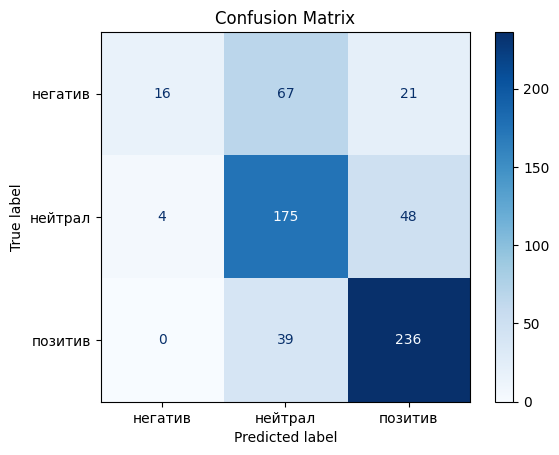

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get class labels in sorted order
labels = model.classes_

# Compute confusion matrix with labels
cm = confusion_matrix(y_valid, y_pred, labels=labels)

# Display confusion matrix with class names
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [63]:
cm_df = pd.DataFrame(
    cm,
    index=model.classes_,
    columns=model.classes_
)

#cm_df

Анализ confusion matrix показывает, что модель хорошо распознаёт класс "позитив", но испытывает сложности с классом "негатив". Значительная часть негативных примеров ошибочно классифицируется как "нейтрал", что говорит о трудностях модели в выявлении негативной тональности. Модель смещена в сторону предсказания "позитив" и "нейтрал", что объясняет разницу между accuracy и F1. Это означает, что дальнейшие улучшения модели должны быть направлены на более качественную обработку меньшего класса, например через балансировку классов или использование более выразительных признаков.

Confusion matrix analysis shows that the model performs well on the "positive" class but struggles with "negative". A significant number of negative samples are misclassified as "neutral", indicating that the model has difficulty capturing negative sentiment. The model is biased towards predicting "positive" and "neutral", which explains the gap between accuracy and F1-score. This suggests that further improvements should focus on better handling of the minority class, for example through class balancing or more expressive text representations.

In [19]:
from sklearn.metrics import precision_score, recall_score

precision_weighted = precision_score(y_valid, y_pred, average='weighted')
recall_weighted = recall_score(y_valid, y_pred, average='weighted')

precision_macro = precision_score(y_valid, y_pred, average='macro')
recall_macro = recall_score(y_valid, y_pred, average='macro')

print("Precision (weighted):", precision_weighted)
print("Recall (weighted):", recall_weighted)
print("Precision (macro):", precision_macro)
print("Recall (macro):", recall_macro)

Precision (weighted): 0.7217112079331147
Recall (weighted): 0.7046204620462047
Precision (macro): 0.7321820975050075
Recall (macro): 0.5943176940533769


In [20]:
precision_per_class = precision_score(y_valid, y_pred, average=None)
recall_per_class = recall_score(y_valid, y_pred, average=None)

print("Classes:", model.classes_)
print("Precision per class:", precision_per_class)
print("Recall per class:", recall_per_class)

Classes: ['негатив' 'нейтрал' 'позитив']
Precision per class: [0.8        0.6227758  0.77377049]
Recall per class: [0.15384615 0.77092511 0.85818182]


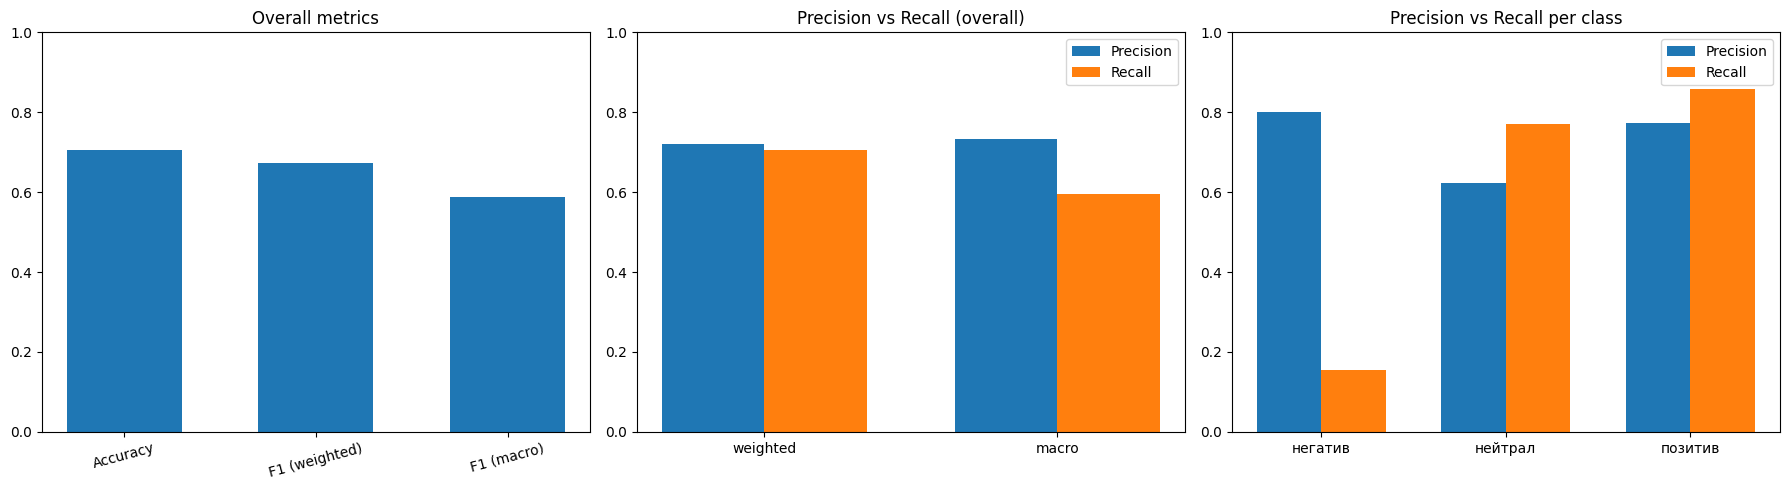

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
avg_metrics_df = pd.DataFrame({
    "Metric": ["weighted", "macro"],
    "Precision": [precision_weighted, precision_macro],
    "Recall": [recall_weighted, recall_macro]
})

per_class_df = pd.DataFrame({
    "Class": model.classes_,
    "Precision": precision_per_class,
    "Recall": recall_per_class
})

overall_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1 (weighted)", "F1 (macro)"],
    "Value": [accuracy, f1, f1_macro]
})

# --- Create subplots (1 row, 3 columns) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Precision vs Recall (weighted / macro) ---
x1 = np.arange(len(avg_metrics_df["Metric"]))
width = 0.35

axes[1].bar(x1 - width/2, avg_metrics_df["Precision"], width=width, label="Precision")
axes[1].bar(x1 + width/2, avg_metrics_df["Recall"], width=width, label="Recall")
axes[1].set_xticks(x1)
axes[1].set_xticklabels(avg_metrics_df["Metric"])
axes[1].set_title("Precision vs Recall (overall)")
axes[1].set_ylim(0, 1)
axes[1].legend()

# --- 2. Precision vs Recall per class ---
x2 = np.arange(len(per_class_df["Class"]))

axes[2].bar(x2 - width/2, per_class_df["Precision"], width=width, label="Precision")
axes[2].bar(x2 + width/2, per_class_df["Recall"], width=width, label="Recall")
axes[2].set_xticks(x2)
axes[2].set_xticklabels(per_class_df["Class"])
axes[2].set_title("Precision vs Recall per class")
axes[2].set_ylim(0, 1)
axes[2].legend()

# --- 3. Overall metrics ---
x3 = np.arange(len(overall_metrics_df["Metric"]))

axes[0].bar(x3, overall_metrics_df["Value"], width=0.6)
axes[0].set_xticks(x3)
axes[0].set_xticklabels(overall_metrics_df["Metric"], rotation=15)
axes[0].set_title("Overall metrics")
axes[0].set_ylim(0, 1)

# --- Adjust layout ---
plt.tight_layout()
plt.show()

# **Accuracy и F1: агрегат + декомпозиция**

Модель показывает высокий precision, но очень низкий recall для класса "негатив". Это означает, что модель осторожно предсказывает негатив: она редко выбирает этот класс, но если выбирает почти всегда права. Однако значительное количество негативных примеров пропускается, что приводит к низкому recall и снижению macro F1.

модель не "ошибается" на негативе\
но она "не решается" на негатив

Модель демонстрирует заметную разницу между weighted и macro F1, что указывает на неравномерное качество по классам. Модель хорошо работает на доминирующих классах, но испытывает трудности с минорным классом ("негатив"), что подтверждается confusion matrix. Это означает, что дальнейшие улучшения должны быть направлены на более качественную обработку минорного класса.

В качестве следующего шага можно улучшить модель, добавив n-grams и методы балансировки классов, чтобы лучше учитывать контекст и повысить качество на минорных классах.

# **Accuracy и F1: aggregated + decomposed**

The model has high precision but very low recall for the "negative" class. This indicates that the model is conservative in predicting negative sentiment: it rarely predicts "negative", but when it does, it is usually correct. However, a large number of negative samples are missed, which leads to poor recall and lower macro F1.

the model is not wrong about negative class\
but it is not decisive about negative class

The model shows a noticeable discrepancy between weighted and macro F1-scores, which indicates uneven performance across classes. While the model performs well on majority classes, it struggles with the minority class ("negative"), as confirmed by the confusion matrix. This suggests that further improvements should focus on better handling of minority class examples.

As a next step, one can improve the model by incorporating n-grams and class balancing techniques to better capture context and improve performance on minority classes.

---

# **Возможное улучшение 1: Биграммы**

TF-IDF расширен биграммами (ngram_range=(1,2)) для учета локального контекста, например коротких фраз. Хотя количество признаков осталось прежним из-за ограничения max_features, их содержание изменилось: теперь используются как отдельные слова, так и биграммы, что позволяет учитывать локальный контекст.

# **Possible improvement 1: Bigrams**


TF-IDF was extended with bigrams (ngram_range=(1,2)) to capture local context such as short phrases. Although the number of features remains the same due to max_features, the feature space has changed: it now includes both unigrams and bigrams, allowing the model to capture local context.

In [22]:
# Initialize TF-IDF with n-grams
vectorizer_ngram = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)  # unigrams + bigrams
)

# Fit on train
X_train_tfidf_ngram = vectorizer_ngram.fit_transform(X_train)

# Transform validation
X_valid_tfidf_ngram = vectorizer_ngram.transform(X_valid)

# Check shapes
print("Train shape:", X_train_tfidf_ngram.shape)
print("Validation shape:", X_valid_tfidf_ngram.shape)

Train shape: (2424, 5000)
Validation shape: (606, 5000)


In [41]:
# Initialize model (same as baseline)
model_ngram = LogisticRegression(max_iter=1000)

# Train model
model_ngram.fit(X_train_tfidf_ngram, y_train)

# Predict on validation
y_pred_ngram = model_ngram.predict(X_valid_tfidf_ngram)

# Calculate metrics
accuracy_ngram = accuracy_score(y_valid, y_pred_ngram)
f1_weighted_ngram = f1_score(y_valid, y_pred_ngram, average='weighted')
f1_macro_ngram = f1_score(y_valid, y_pred_ngram, average='macro')

print("Accuracy (ngram):", accuracy_ngram)
print("F1 weighted (ngram):", f1_weighted_ngram)
print("F1 macro (ngram):", f1_macro_ngram)

Accuracy (ngram): 0.698019801980198
F1 weighted (ngram): 0.6665815865690168
F1 macro (ngram): 0.5855716658950407


In [52]:
import pandas as pd

# Create comparison table
df_ngram = pd.DataFrame({
    "Metric": ["Accuracy", "F1 weighted", "F1 macro"],
    "Baseline": [accuracy, f1, f1_macro],
    "N-grams": [accuracy_ngram, f1_weighted_ngram, f1_macro_ngram]
})

# Add delta with arrows
def format_delta(new, base):
    diff = new - base
    arrow = "↑" if diff > 0 else "↓" if diff < 0 else "→"
    return f"{new:.4f} ({arrow}{abs(diff):.4f})"

df_ngram["N-grams"] = [
    format_delta(n, b) for n, b in zip(df_ngram["N-grams"], df_ngram["Baseline"])
]

df_ngram["Baseline"] = df_ngram["Baseline"].map(lambda x: f"{x:.4f}")

df_ngram.set_index("Metric")

,Baseline,N-grams
Metric,,
Accuracy,0.7046,0.6980 (↓0.0066)
F1 weighted,0.6717,0.6666 (↓0.0051)
F1 macro,0.5869,0.5856 (↓0.0014)


Добавление n-грамм не улучшило качество модели. Это может быть связано с ограничением числа признаков (max_features=5000), из-за которого биграммы вытеснили часть информативных униграмм, а также с увеличением разреженности и шума в признаковом пространстве. Кроме того, относительно небольшой размер выборки делает биграммы менее устойчивыми признаками.

The introduction of n-grams did not improve performance. This may be due to the fixed feature limit (max_features=5000), where bigrams replaced some informative unigrams, as well as increased sparsity and noise in the feature space. Additionally, the relatively small dataset size makes bigram features less reliable.

In [24]:
# Train metrics
y_train_pred_ngram = model_ngram.predict(X_train_tfidf_ngram)

train_acc_ngram = accuracy_score(y_train, y_train_pred_ngram)
train_f1_ngram = f1_score(y_train, y_train_pred_ngram, average='weighted')

print("Train accuracy (ngram):", train_acc_ngram)
print("Train F1 (ngram):", train_f1_ngram)

Train accuracy (ngram): 0.8655115511551155
Train F1 (ngram): 0.8594468954231197


In [67]:
df_ngram_model = pd.DataFrame({
    "Metric": ["Accuracy", "F1 weighted", "F1 macro"],
    "Train": [
        train_acc_ngram,
        train_f1_ngram,
        f1_score(y_train, y_train_pred_ngram, average='macro')
    ],
    "Validation": [
        accuracy_ngram,
        f1_weighted_ngram,
        f1_macro_ngram
    ]
})

df_ngram_model["Gap"] = df_ngram_model["Train"] - df_ngram_model["Validation"]

df_ngram_model = df_ngram_model.round(4).set_index("Metric")
df_ngram_model

,Train,Validation,Gap
Metric,,,
Accuracy,0.8655,0.6980,0.1675
F1 weighted,0.8594,0.6666,0.1929
F1 macro,0.8305,0.5856,0.2450


Модель остаётся переобученной: сохраняется разрыв между обучающей и валидационной выборками (~0.17). Добавление n-грамм не уменьшило переобучение и немного ухудшило качество на валидации. Увеличение max_features может сохранить больше информативных униграмм, однако из-за небольшого размера выборки это, скорее всего, приведёт к росту разреженности и усилению переобучения.

The model remains overfitted: there is a consistent gap between training and validation performance (~0.17). The introduction of n-grams did not reduce overfitting and slightly degraded validation performance. Increasing max_features could preserve more informative unigrams, but given the small dataset size, it would likely increase sparsity and overfitting.

In [40]:
cm_ngram = confusion_matrix(y_valid, y_pred_ngram, labels=model_ngram.classes_)

cm_ngram_df = pd.DataFrame(
    cm_ngram,
    index=model_ngram.classes_,
    columns=model_ngram.classes_
)

#cm_ngram_df

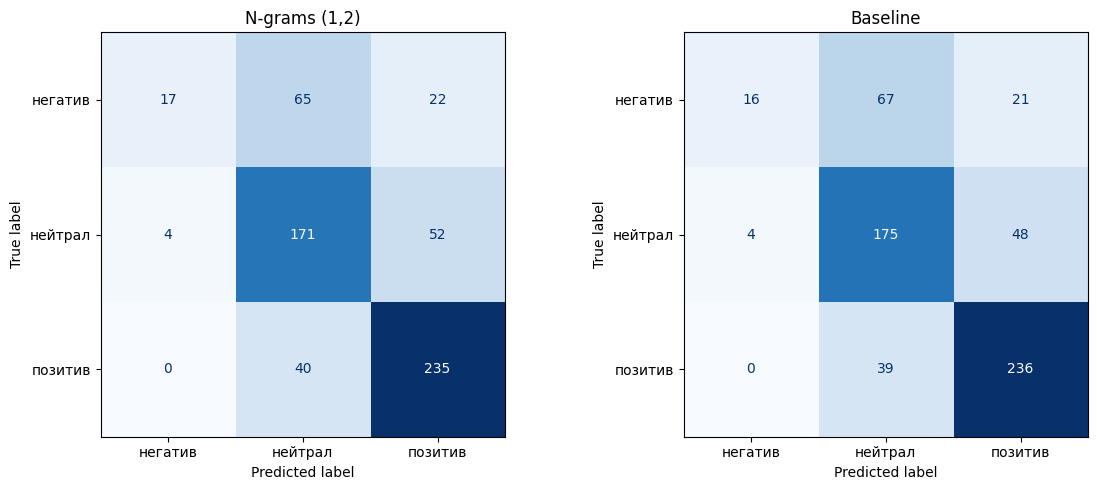

In [39]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Baseline ---
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp1.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title("Baseline")

# --- N-grams ---
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_ngram, display_labels=labels)
disp2.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title("N-grams (1,2)")

plt.tight_layout()
plt.show()

Матрицы ошибок практически совпадают, следовательно декомпозиция метрик будет тоже практически совпадать.

Confusion matrices are nearly identical, therefore metric decomposition will be nearly the same as well.

---

# **Возможное улучшение 2: Сlass Balance**

Для учёта дисбаланса классов была применена настройка class_weight='balanced' в логистической регрессии. Она автоматически увеличивает вес редких классов и уменьшает вес доминирующих, за счёт чего ошибки на минорных классах (например, "негатив") сильнее штрафуются. Цель повысить recall и качество модели на редких классах, даже если это приведёт к небольшому снижению общей accuracy. Это позволяет модели уделять больше внимания минорным классам, что особенно важно при дисбалансе, когда стандартное обучение приводит к смещению в сторону доминирующих классов.

# **Possible improvement 2: Сlass Balance**

To address class imbalance, I applied class_weight='balanced' in Logistic Regression. This automatically assigns higher weights to minority classes and lower weights to majority classes during training. As a result, errors on underrepresented classes (such as "negative") are penalized more strongly. The goal is to improve recall and overall performance on minority classes, even if it slightly reduces overall accuracy. This approach helps the model pay more attention to minority classes, which is especially important in imbalanced datasets where standard training may bias predictions towards majority classes.

In [60]:
# Initialize model with class balancing
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

# Train model
model_balanced.fit(X_train_tfidf, y_train)

# Predict
y_pred_balanced = model_balanced.predict(X_valid_tfidf)

# Metrics
accuracy_balanced = accuracy_score(y_valid, y_pred_balanced)
f1_weighted_balanced = f1_score(y_valid, y_pred_balanced, average='weighted')
f1_macro_balanced = f1_score(y_valid, y_pred_balanced, average='macro')

print("Accuracy (balanced):", accuracy_balanced)
print("F1 weighted (balanced):", f1_weighted_balanced)
print("F1 macro (balanced):", f1_macro_balanced)

Accuracy (balanced): 0.6996699669966997
F1 weighted (balanced): 0.7015314964179893
F1 macro (balanced): 0.6428993002393023


In [57]:
df_balanced = pd.DataFrame({
    "Metric": ["Accuracy", "F1 weighted", "F1 macro"],
    "Baseline": [accuracy, f1, f1_macro],
    "Balanced": [accuracy_balanced, f1_weighted_balanced, f1_macro_balanced]
})

df_balanced["Balanced"] = [
    format_delta(n, b) for n, b in zip(df_balanced["Balanced"], df_balanced["Baseline"])
]

df_balanced["Baseline"] = df_balanced["Baseline"].map(lambda x: f"{x:.4f}")

df_balanced.set_index("Metric")

,Baseline,Balanced
Metric,,
Accuracy,0.7046,0.6997 (↓0.0050)
F1 weighted,0.6717,0.7015 (↑0.0299)
F1 macro,0.5869,0.6429 (↑0.0560)


In [58]:
df_all = pd.DataFrame({
    "Metric": ["Accuracy", "F1 weighted", "F1 macro"],
    "Baseline": [accuracy, f1, f1_macro],
    "N-grams": [accuracy_ngram, f1_weighted_ngram, f1_macro_ngram],
    "Balanced": [accuracy_balanced, f1_weighted_balanced, f1_macro_balanced]
})

# Format baseline
df_all["Baseline"] = df_all["Baseline"].map(lambda x: f"{x:.4f}")

# Format comparisons
df_all["N-grams"] = [
    format_delta(n, b) for n, b in zip(df_all["N-grams"], [accuracy, f1, f1_macro])
]

df_all["Balanced"] = [
    format_delta(n, b) for n, b in zip(df_all["Balanced"], [accuracy, f1, f1_macro])
]

df_all.set_index("Metric")

,Baseline,N-grams,Balanced
Metric,,,
Accuracy,0.7046,0.6980 (↓0.0066),0.6997 (↓0.0050)
F1 weighted,0.6717,0.6666 (↓0.0051),0.7015 (↑0.0299)
F1 macro,0.5869,0.5856 (↓0.0014),0.6429 (↑0.0560)


Использование class_weight='balanced' улучшило качество модели по F1, особенно macro F1. Указывает на улучшение качества на минорном классе ("негатив"). Модель стала более сбалансированной по классам.

Applying class_weight='balanced' improved model performance in terms of F1-score, especially macro F1, which increased significantly. This indicates better performance on the minority class "negative". The model became more balanced across classes.

In [59]:
# Evaluate on train (balanced model)
y_train_pred_balanced = model_balanced.predict(X_train_tfidf)

train_acc_balanced = accuracy_score(y_train, y_train_pred_balanced)
train_f1_balanced = f1_score(y_train, y_train_pred_balanced, average='weighted')

print("Train Accuracy (balanced):", train_acc_balanced)
print("Train F1 (balanced):", train_f1_balanced)

Train Accuracy (balanced): 0.9014026402640264
Train F1 (balanced): 0.9016279160410328


In [68]:
df_balanced_model = pd.DataFrame({
    "Metric": ["Accuracy", "F1 weighted", "F1 macro"],
    "Train": [
        train_acc_balanced,
        train_f1_balanced,
        f1_score(y_train, y_train_pred_balanced, average='macro')
    ],
    "Validation": [
        accuracy_balanced,
        f1_weighted_balanced,
        f1_macro_balanced
    ]
})

df_balanced_model["Gap"] = df_balanced_model["Train"] - df_balanced_model["Validation"]

df_balanced_model = df_balanced_model.round(4).set_index("Metric")
df_balanced_model

,Train,Validation,Gap
Metric,,,
Accuracy,0.9014,0.6997,0.2017
F1 weighted,0.9016,0.7015,0.2001
F1 macro,0.9011,0.6429,0.2582


In [69]:
import pandas as pd

# Create overfitting gap table
df_gap = pd.DataFrame({
    "Model": ["Baseline", "N-grams", "Balanced"],
    "Accuracy gap": [0.1646, 0.1675, 0.2017],
    "F1 weighted gap": [0.1922, 0.1929, 0.2001],
    "F1 macro gap": [0.2493, 0.2450, 0.2582]
})

df_gap = df_gap.set_index("Model")

df_gap

,Accuracy gap,F1 weighted gap,F1 macro gap
Model,,,
Baseline,0.1646,0.1922,0.2493
N-grams,0.1675,0.1929,0.2450
Balanced,0.2017,0.2001,0.2582


Модель с балансировкой классов улучшает качество на валидации, особенно по F1 (weighted и macro), что указывает на лучшее распознавание минорного класса. **Однако это сопровождается усилением переобучения, что видно по увеличенному разрыву между train и validation.** Таким образом, наблюдается компромисс между качеством по классам и обобщающей способностью модели.

The balanced model improves performance on the validation set, especially in terms of F1-score (both weighted and macro), indicating better handling of the minority class. **However, this comes at the cost of increased overfitting, as shown by a larger gap between training and validation metrics.** This suggests a trade-off between class-level performance and generalization.

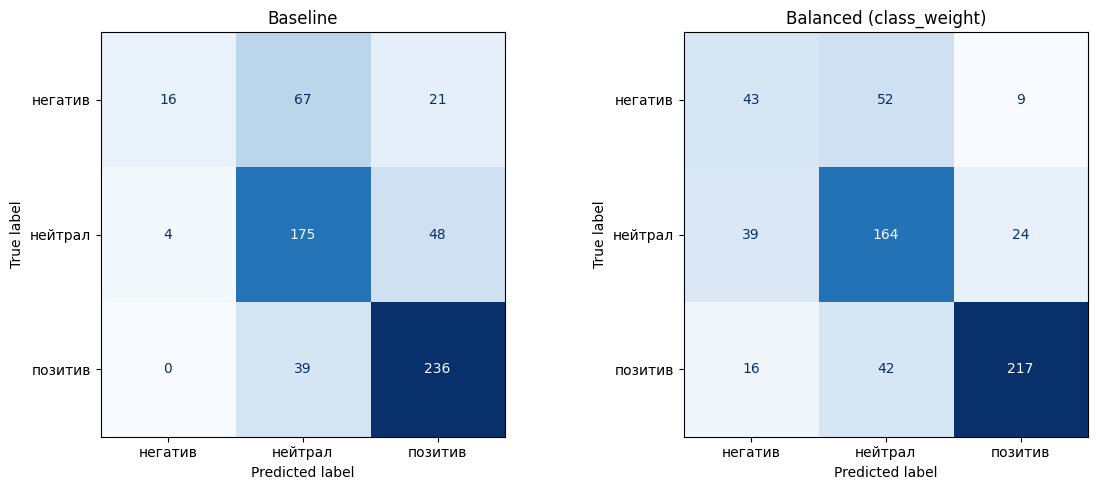

In [71]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Baseline ---
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp1.plot(cmap='Blues', ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Baseline")

# --- Balanced ---
cm_balanced = confusion_matrix(y_valid, y_pred_balanced, labels=labels)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=labels)
disp2.plot(cmap='Blues', ax=axes[1], colorbar=False, values_format='d')
axes[1].set_title("Balanced (class_weight)")

plt.tight_layout()
plt.show()

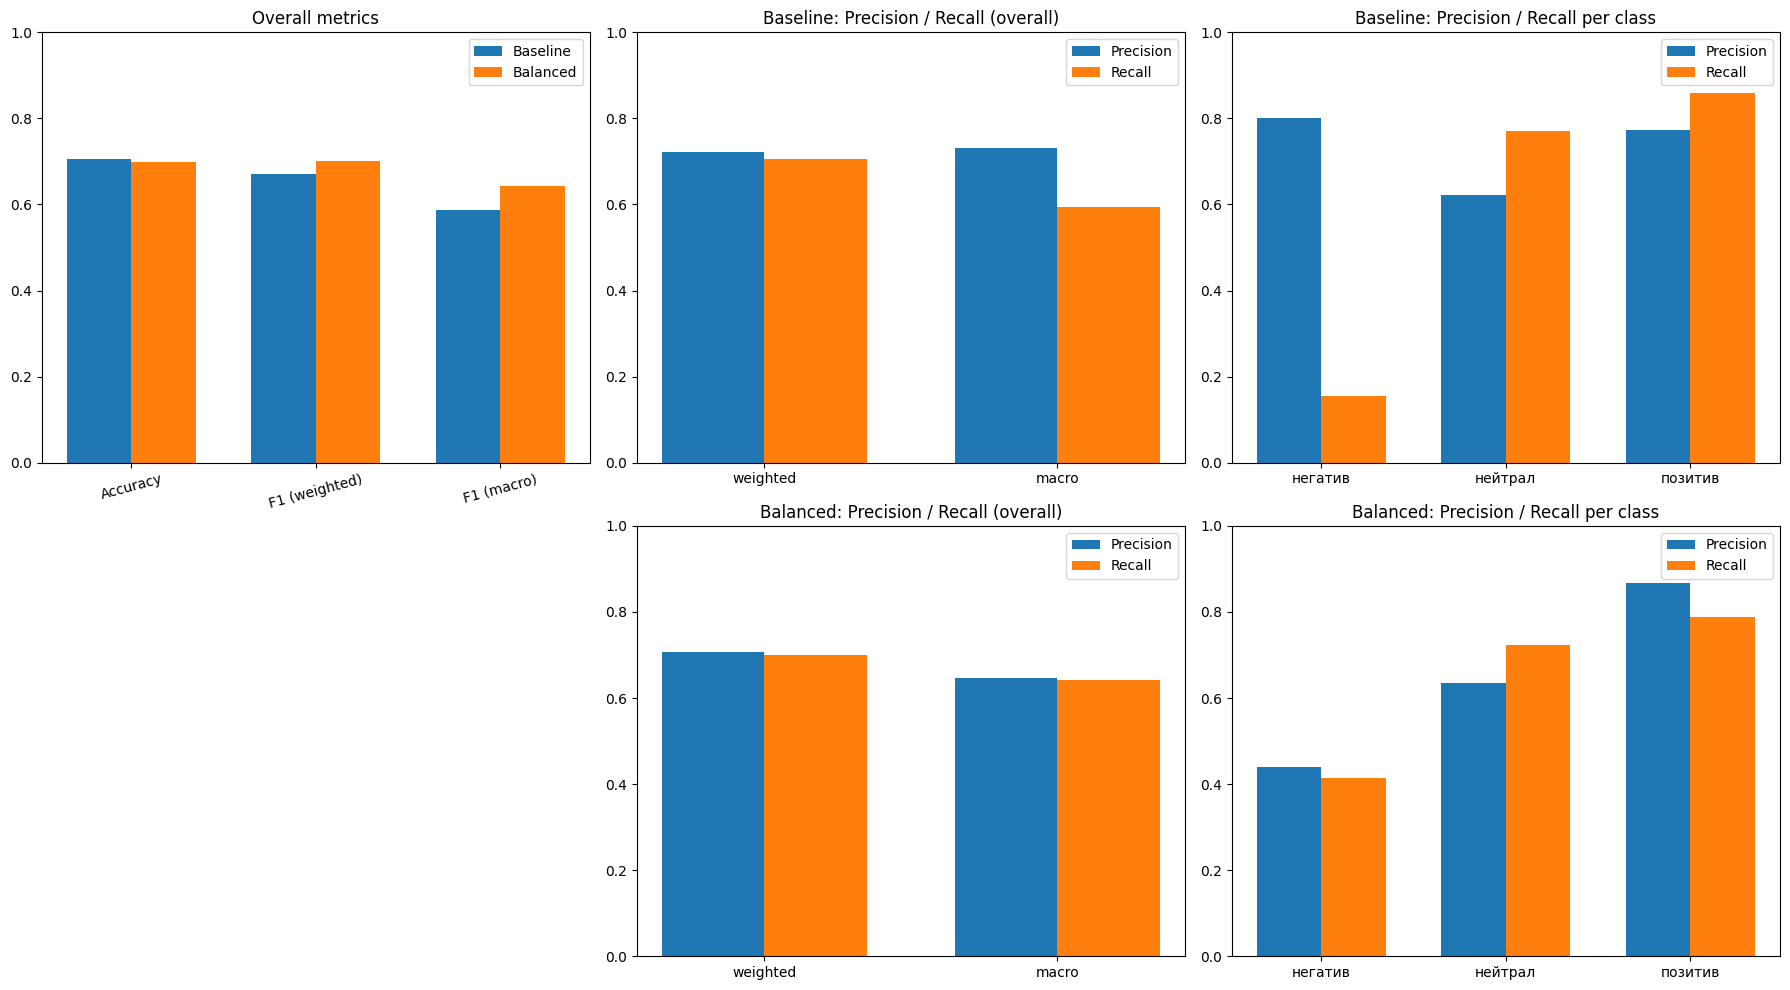

In [74]:
# --- Prepare balanced metrics ---
precision_weighted_balanced = precision_score(y_valid, y_pred_balanced, average='weighted')
recall_weighted_balanced = recall_score(y_valid, y_pred_balanced, average='weighted')

precision_macro_balanced = precision_score(y_valid, y_pred_balanced, average='macro')
recall_macro_balanced = recall_score(y_valid, y_pred_balanced, average='macro')

precision_per_class_balanced = precision_score(y_valid, y_pred_balanced, average=None)
recall_per_class_balanced = recall_score(y_valid, y_pred_balanced, average=None)

# --- Prepare dataframes ---

# Overall metrics: baseline vs balanced
overall_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1 (weighted)", "F1 (macro)"],
    "Baseline": [accuracy, f1, f1_macro],
    "Balanced": [accuracy_balanced, f1_weighted_balanced, f1_macro_balanced]
})

# Overall precision/recall: baseline
avg_metrics_baseline_df = pd.DataFrame({
    "Metric": ["weighted", "macro"],
    "Precision": [precision_weighted, precision_macro],
    "Recall": [recall_weighted, recall_macro]
})

# Overall precision/recall: balanced
avg_metrics_balanced_df = pd.DataFrame({
    "Metric": ["weighted", "macro"],
    "Precision": [precision_weighted_balanced, precision_macro_balanced],
    "Recall": [recall_weighted_balanced, recall_macro_balanced]
})

# Per-class precision/recall: baseline
per_class_baseline_df = pd.DataFrame({
    "Class": model.classes_,
    "Precision": precision_per_class,
    "Recall": recall_per_class
})

# Per-class precision/recall: balanced
per_class_balanced_df = pd.DataFrame({
    "Class": model.classes_,
    "Precision": precision_per_class_balanced,
    "Recall": recall_per_class_balanced
})

# --- Create subplots: 2 rows x 3 columns ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
width = 0.35

# --- Top-left: overall metrics (baseline vs balanced) ---
x0 = np.arange(len(overall_metrics_df["Metric"]))

axes[0, 0].bar(x0 - width/2, overall_metrics_df["Baseline"], width=width, label="Baseline")
axes[0, 0].bar(x0 + width/2, overall_metrics_df["Balanced"], width=width, label="Balanced")
axes[0, 0].set_xticks(x0)
axes[0, 0].set_xticklabels(overall_metrics_df["Metric"], rotation=15)
axes[0, 0].set_title("Overall metrics")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend()

# --- Top-center: baseline overall precision/recall ---
x1 = np.arange(len(avg_metrics_baseline_df["Metric"]))

axes[0, 1].bar(x1 - width/2, avg_metrics_baseline_df["Precision"], width=width, label="Precision")
axes[0, 1].bar(x1 + width/2, avg_metrics_baseline_df["Recall"], width=width, label="Recall")
axes[0, 1].set_xticks(x1)
axes[0, 1].set_xticklabels(avg_metrics_baseline_df["Metric"])
axes[0, 1].set_title("Baseline: Precision / Recall (overall)")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()

# --- Top-right: baseline per-class precision/recall ---
x2 = np.arange(len(per_class_baseline_df["Class"]))

axes[0, 2].bar(x2 - width/2, per_class_baseline_df["Precision"], width=width, label="Precision")
axes[0, 2].bar(x2 + width/2, per_class_baseline_df["Recall"], width=width, label="Recall")
axes[0, 2].set_xticks(x2)
axes[0, 2].set_xticklabels(per_class_baseline_df["Class"])
axes[0, 2].set_title("Baseline: Precision / Recall per class")
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()

# --- Bottom-left: empty panel ---
axes[1, 0].axis("off")

# --- Bottom-center: balanced overall precision/recall ---
x3 = np.arange(len(avg_metrics_balanced_df["Metric"]))

axes[1, 1].bar(x3 - width/2, avg_metrics_balanced_df["Precision"], width=width, label="Precision")
axes[1, 1].bar(x3 + width/2, avg_metrics_balanced_df["Recall"], width=width, label="Recall")
axes[1, 1].set_xticks(x3)
axes[1, 1].set_xticklabels(avg_metrics_balanced_df["Metric"])
axes[1, 1].set_title("Balanced: Precision / Recall (overall)")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()

# --- Bottom-right: balanced per-class precision/recall ---
x4 = np.arange(len(per_class_balanced_df["Class"]))

axes[1, 2].bar(x4 - width/2, per_class_balanced_df["Precision"], width=width, label="Precision")
axes[1, 2].bar(x4 + width/2, per_class_balanced_df["Recall"], width=width, label="Recall")
axes[1, 2].set_xticks(x4)
axes[1, 2].set_xticklabels(per_class_balanced_df["Class"])
axes[1, 2].set_title("Balanced: Precision / Recall per class")
axes[1, 2].set_ylim(0, 1)
axes[1, 2].legend()

# --- Adjust layout ---
plt.tight_layout()
plt.show()

Использование class_weight='balanced' привело к снижению accuracy и росту F1, особенно macro F1. Это означает, что модель стала лучше работать с минорным классом ("негатив") и более равномерно распределять качество между классами. Таким образом, балансировка классов улучшает качество решения задачи ценой небольшого ухудшения общей точности.

Applying class_weight='balanced' slightly decreases accuracy and improves F1, especially macro F1. This indicates better performance on the minority class ("negative") and more balanced predictions across classes. Thus, class balancing improves task-relevant performance at the cost of a small decrease in overall accuracy.

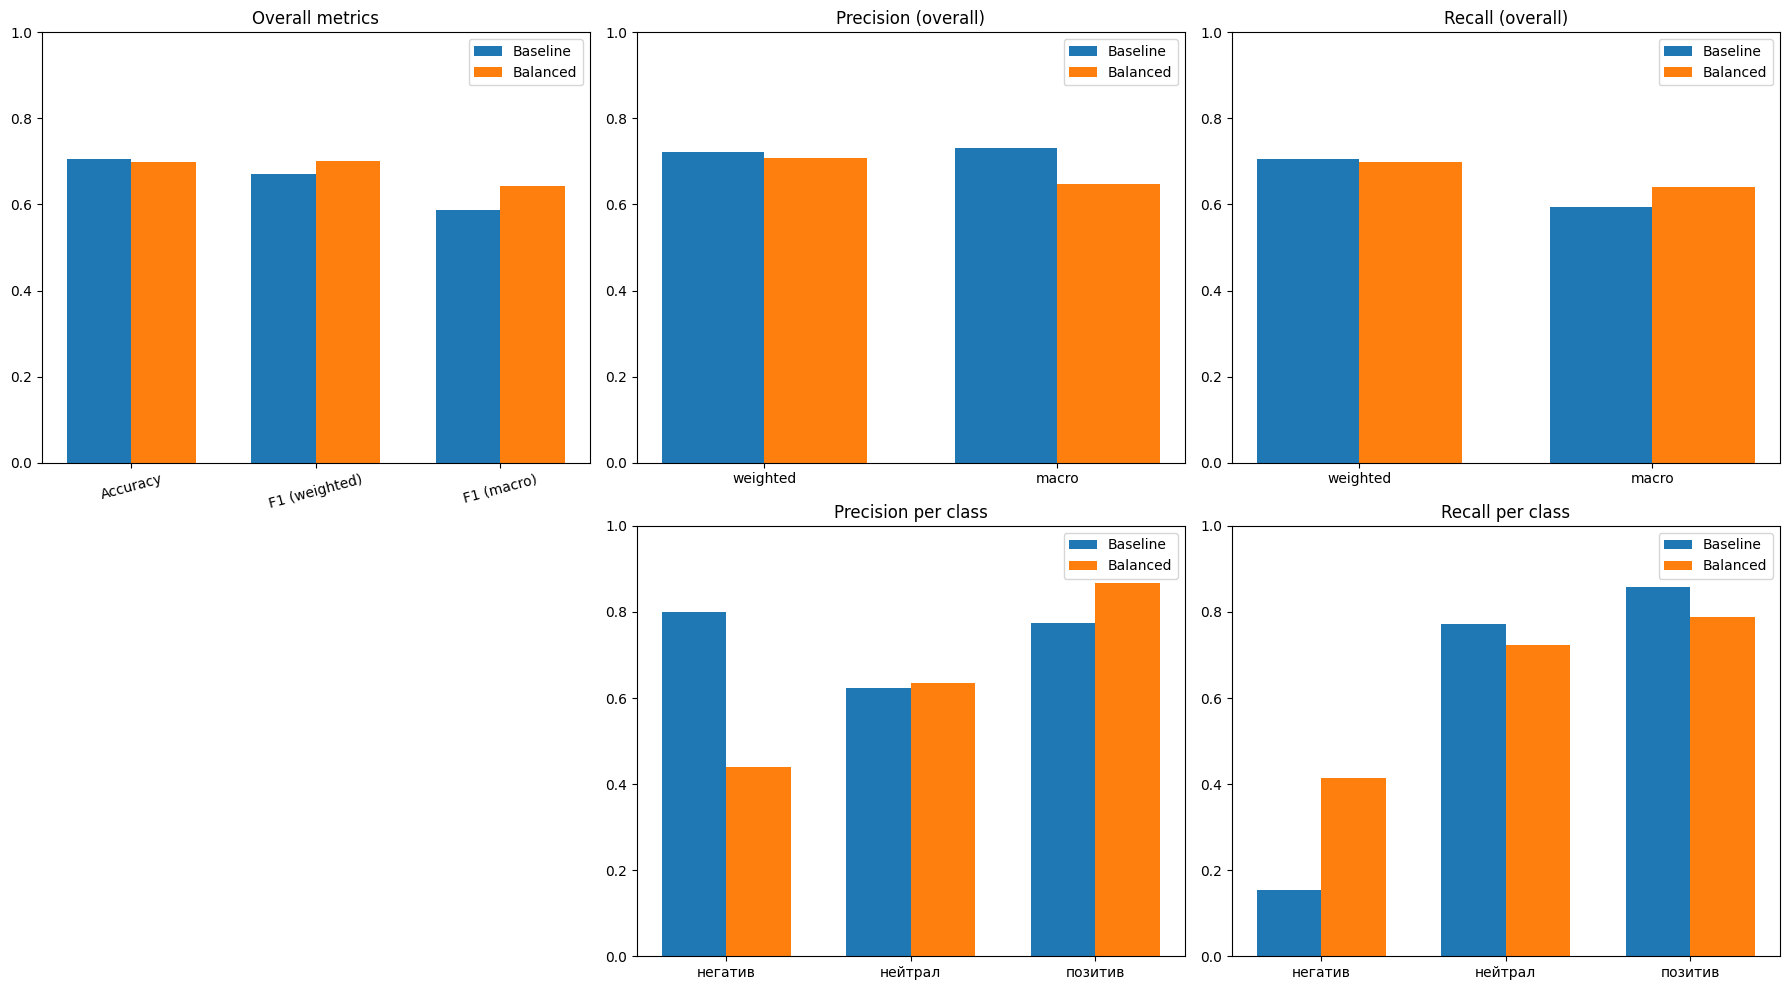

In [75]:
# --- Prepare positions ---
width = 0.35

# --- Create figure ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ========================
# 1. Overall metrics (same)
# ========================
x0 = np.arange(len(overall_metrics_df["Metric"]))

axes[0, 0].bar(x0 - width/2, overall_metrics_df["Baseline"], width=width, label="Baseline")
axes[0, 0].bar(x0 + width/2, overall_metrics_df["Balanced"], width=width, label="Balanced")

axes[0, 0].set_xticks(x0)
axes[0, 0].set_xticklabels(overall_metrics_df["Metric"], rotation=15)
axes[0, 0].set_title("Overall metrics")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend()

# ========================
# 2. Precision (overall)
# ========================
x1 = np.arange(2)  # weighted, macro

axes[0, 1].bar(x1 - width/2,
               [precision_weighted, precision_macro],
               width=width, label="Baseline")

axes[0, 1].bar(x1 + width/2,
               [precision_weighted_balanced, precision_macro_balanced],
               width=width, label="Balanced")

axes[0, 1].set_xticks(x1)
axes[0, 1].set_xticklabels(["weighted", "macro"])
axes[0, 1].set_title("Precision (overall)")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()

# ========================
# 3. Recall (overall)
# ========================
axes[0, 2].bar(x1 - width/2,
               [recall_weighted, recall_macro],
               width=width, label="Baseline")

axes[0, 2].bar(x1 + width/2,
               [recall_weighted_balanced, recall_macro_balanced],
               width=width, label="Balanced")

axes[0, 2].set_xticks(x1)
axes[0, 2].set_xticklabels(["weighted", "macro"])
axes[0, 2].set_title("Recall (overall)")
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()

# ========================
# 4. Empty panel
# ========================
axes[1, 0].axis("off")

# ========================
# 5. Precision per class
# ========================
x2 = np.arange(len(model.classes_))

axes[1, 1].bar(x2 - width/2, precision_per_class, width=width, label="Baseline")
axes[1, 1].bar(x2 + width/2, precision_per_class_balanced, width=width, label="Balanced")

axes[1, 1].set_xticks(x2)
axes[1, 1].set_xticklabels(model.classes_)
axes[1, 1].set_title("Precision per class")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()

# ========================
# 6. Recall per class
# ========================
axes[1, 2].bar(x2 - width/2, recall_per_class, width=width, label="Baseline")
axes[1, 2].bar(x2 + width/2, recall_per_class_balanced, width=width, label="Balanced")

axes[1, 2].set_xticks(x2)
axes[1, 2].set_xticklabels(model.classes_)
axes[1, 2].set_title("Recall per class")
axes[1, 2].set_ylim(0, 1)
axes[1, 2].legend()

# --- Layout ---
plt.tight_layout()
plt.show()

Балансировка классов существенно увеличила recall для класса "негатив". Это означает, что модель стала лучше находить негативные примеры. Однако это сопровождается снижением precision, то есть увеличением числа ложных срабатываний. Таким образом, модель переходит от консервативной стратегии к более агрессивной.

Class balancing significantly increases recall for the "negative" class, meaning the model detects more negative samples. However, this comes at the cost of lower precision, leading to more false positives. This reflects a shift from a conservative to a more aggressive prediction strategy.

---

# **Выводы**

Базовая модель (TF-IDF + логистическая регрессия) показала удовлетворительное качество (accuracy ~0.70), однако анализ confusion matrix и метрик по классам выявил слабую работу с минорным классом ("негатив"), особенно низкий recall.

Добавление н-грамм не улучшило качество модели, что указывает на то, что основное ограничение связано не с признаками, а с дисбалансом классов.

Использование class_weight='balanced' позволило существенно улучшить F1, особенно macro F1, за счёт увеличения recall для класса "негатив".

При этом увеличилось количество ложных срабатываний и немного снизилась accuracy, что отражает компромисс между общей точностью и равномерным качеством по классам.

Анализ метрик на обучающей и валидационной выборках показал наличие переобучения во всех моделях: наблюдается стабильный разрыв между train и validation (≈0.16–0.25 по различным метрикам). Добавление н-грамм не повлияло на уровень переобучения, а использование балансировки классов даже немного его усилило, что связано с более агрессивным подстраиванием модели под сложный минорный класс.

Таким образом, текущие улучшения влияют на распределение качества по классам, но не решают проблему обобщающей способности модели.

В результате финальная модель обеспечивает более сбалансированное качество по всем классам, что является более корректным решением для данной задачи.

# **Conclusions**

The baseline model (TF-IDF + Logistic Regression) achieved satisfactory performance (accuracy ~0.70). However, analysis of the confusion matrix and class-level metrics revealed poor performance on the minority class ("negative"), particularly very low recall.

Adding n-grams did not improve model performance, indicating that the main limitation is not feature representation but class imbalance.

Applying class_weight='balanced' significantly improved F1 scores, especially macro F1, by increasing recall for the "negative" class.

However, this also led to an increase in false positives and a slight decrease in accuracy, reflecting a trade-off between overall accuracy and balanced performance across classes.

Analysis of training and validation metrics showed the presence of overfitting in all models: a consistent gap between train and validation performance is observed (≈0.16–0.25 across different metrics). Adding n-grams did not affect the level of overfitting, while class balancing slightly increased it, likely due to more aggressive fitting to the difficult minority class.

Thus, the applied improvements affect the distribution of performance across classes but do not resolve the generalization issue.

As a result, the final model provides more balanced performance across all classes, which is more appropriate for this task.